# End-to-end Machine Learning project

Based on the book "Hands-On Machine Learning with Scikit-Learn and TensorFlow" by Aurélien Géron

Adapted from original [notebook](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb) by Aurélien Géron 
This notebook requires Python 3.7 or later and scikit-learn 1.0.1 or later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import KNNImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.feature_selection import SelectFromModel
from pandas.plotting import scatter_matrix

In [2]:
housing = pd.read_csv("housing.csv")

In [3]:
# look at the first few rows of the housing dataframe
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# summarize the data
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# just one categorical feature
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Before doing much more, split!
train, test = train_test_split(housing, test_size=0.2, random_state=42)

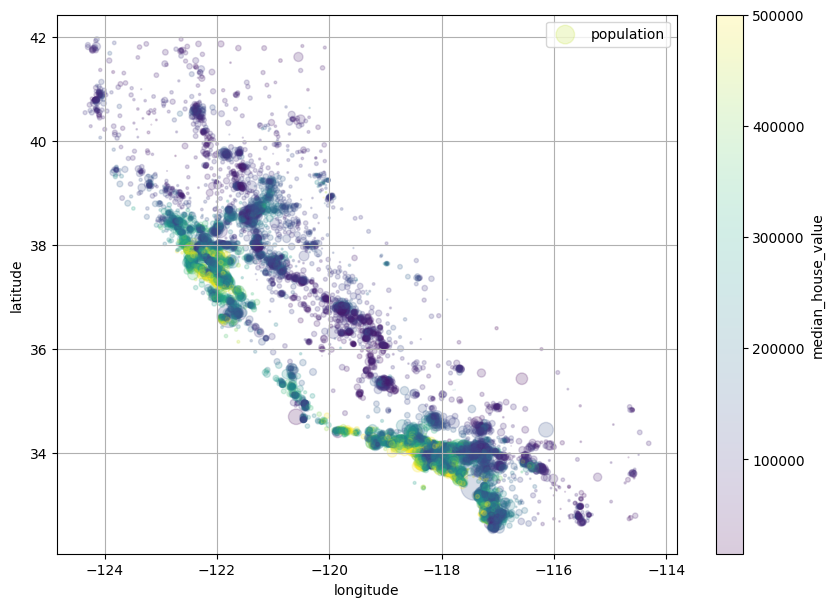

In [8]:
# how about a heat map?
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="viridis", colorbar=True,
             legend=True, figsize=(10, 7), alpha=0.2)
plt.show()

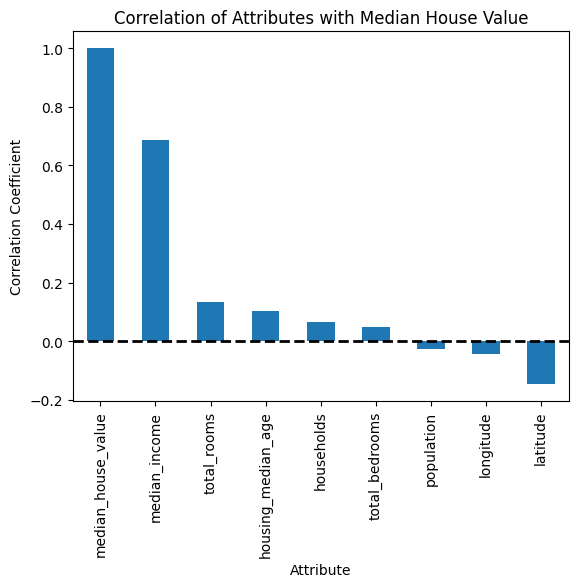

In [9]:
# is anything correlated with the target?
corr_matrix = train.corr(numeric_only=True)
corr_sorted = corr_matrix["median_house_value"].sort_values(ascending=False)
corr_sorted.plot(kind="bar")
plt.plot([-0.5, len(corr_sorted)], [0, 0], "k--", linewidth=2)
plt.xticks(rotation=90)
plt.xlabel("Attribute")
plt.ylabel("Correlation Coefficient")
plt.title("Correlation of Attributes with Median House Value")
plt.show()
# median income looks pretty strong!

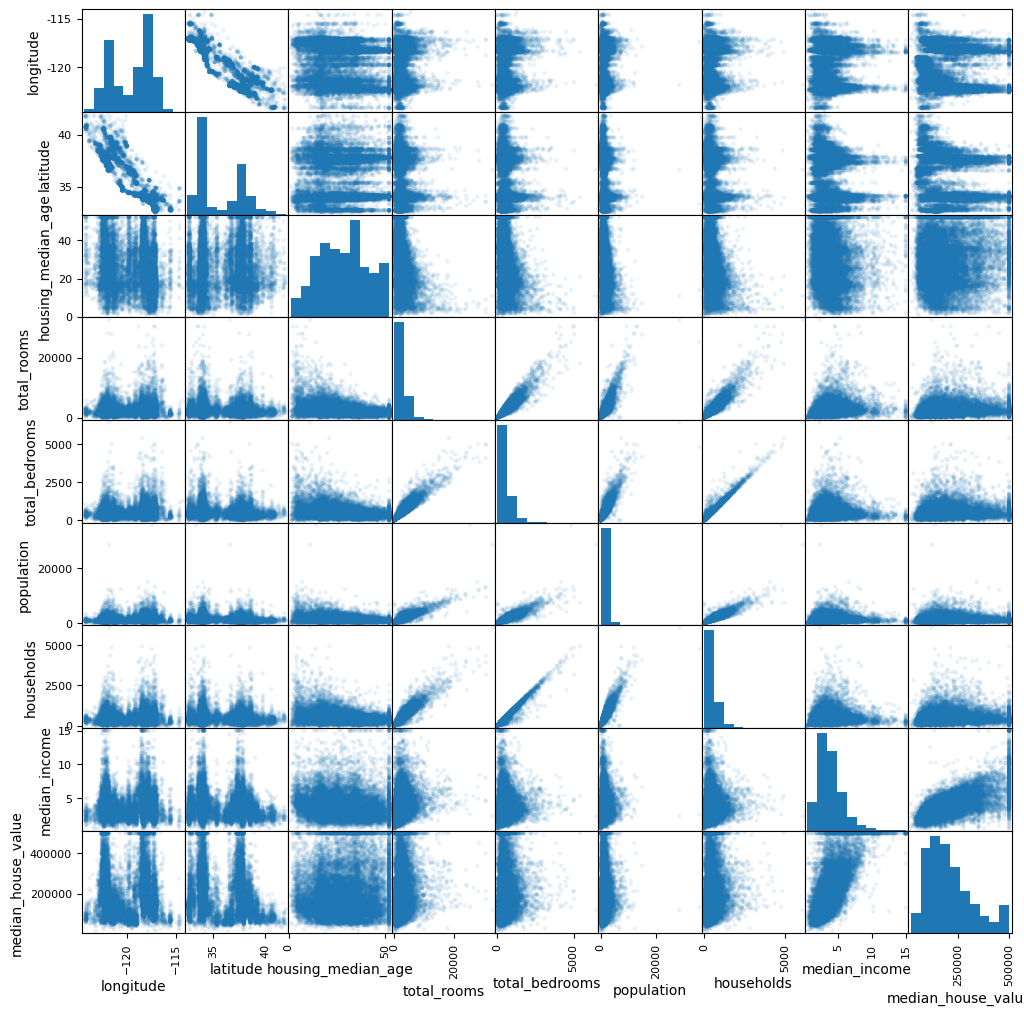

In [10]:
# What kinds of scales are we looking at?
scatter_matrix(train, figsize=(12, 12), alpha=0.1)
plt.show()

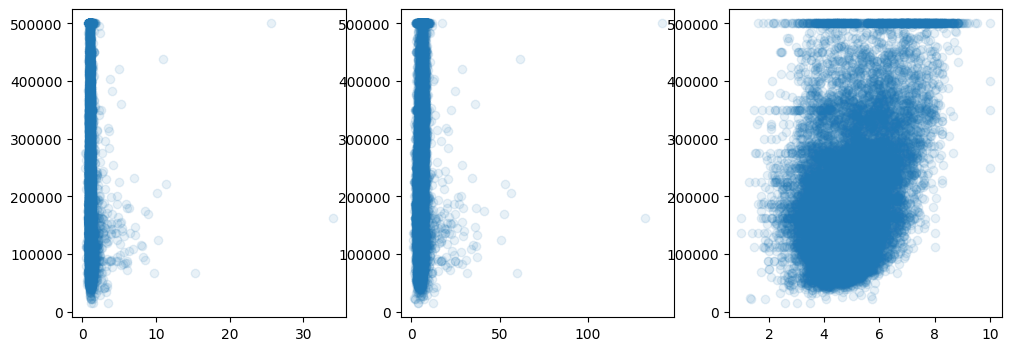

In [11]:
# total bedrooms and total rooms are pretty weird numbers
# Maybe divide by houses per district?
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].scatter(train["total_bedrooms"] / train["households"], train["median_house_value"], alpha=0.1)
axes[1].scatter(train["total_rooms"] / train["households"], train["median_house_value"], alpha=0.1)
axes[2].scatter(train["total_rooms"] / train["total_bedrooms"], train["median_house_value"], alpha=0.1)
# ehhh

<Axes: title={'center': 'median_house_value'}, xlabel='ocean_proximity'>

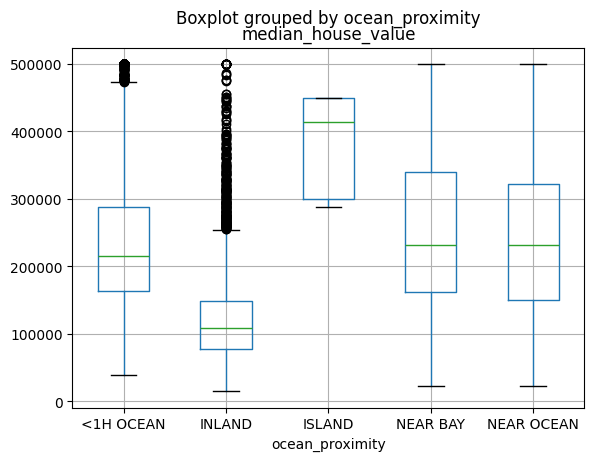

In [12]:
train.boxplot(column="median_house_value", by="ocean_proximity")

## Missing features

In [13]:
# First, let's look at the missing values in the total_bedrooms column
null_rows_idx = train.isnull().any(axis=1)
print(f"Missing {len(train[null_rows_idx])} of {len(train)} rows")
train.loc[null_rows_idx].head()

Missing 163 of 16512 rows


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9529,-118.31,33.94,40.0,1550.0,NaN,798.0,270.0,3.7750,153800.0,<1H OCEAN
16519,-117.86,34.01,16.0,4632.0,NaN,3038.0,727.0,5.1762,264400.0,<1H OCEAN
19782,-119.75,34.45,6.0,2864.0,NaN,1404.0,603.0,5.5073,263800.0,NEAR OCEAN
1343,-120.32,37.29,38.0,576.0,NaN,478.0,112.0,2.3382,59600.0,INLAND
9827,-121.85,36.61,38.0,238.0,NaN,191.0,67.0,1.3897,125000.0,<1H OCEAN


In [14]:
# This seems like a pretty good situation for a KNN imputer
imputer = KNNImputer()

## Categorical Encoding

In [15]:
# Option 1: Ordinal encoding
# naive implementation
# If ordinal, needs to make sense - default values are alphabetical
ordinal_encoder = OrdinalEncoder(categories = [["ISLAND", "NEAR BAY", "NEAR OCEAN", "<1H OCEAN", "INLAND"]])

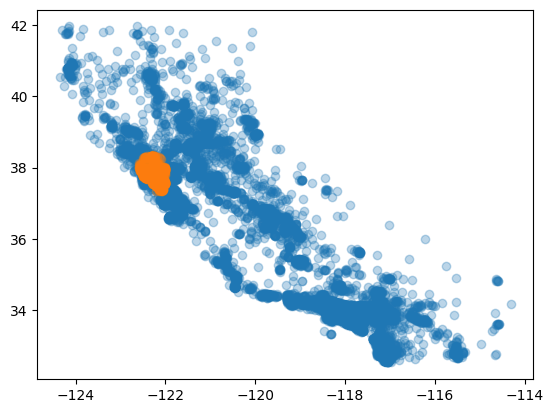

In [16]:
# Let's confirm what "near bay" means - San Francisco Bay area?
near_bay = train["ocean_proximity"] == "NEAR BAY"
plt.scatter(train["longitude"],train["latitude"], alpha=0.3)
plt.scatter(train["longitude"][near_bay],train["latitude"][near_bay], alpha=0.3)

## Transformation Pipelines

Data transformations are so common that most frameworks have a way of handling them efficiently. We'll set up a pipeline of functional transformations that will be applied to the data in sequence. A key thing to note is that the pipeline is fit to the **training data** - you should never re-normalize based on test data, for example.

In [23]:
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]

# define a custom function to use with a FunctionTransformer
def column_ratio(X):
    return X[:, [0]] * X[:, [1]]

# and a function for convenient stacking of imputer/ratio/scaling
def ratio_pipeline():
    return make_pipeline(
        imputer,
        FunctionTransformer(column_ratio),
        StandardScaler())

# The numeric features get the usual treatment
num_pipeline = make_pipeline(
    imputer,
    PolynomialFeatures(interaction_only=True),
    StandardScaler(),
)

# altogether now
preprocessing = make_column_transformer(
    (num_pipeline, num_attribs),
    # (ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    # (ratio_pipeline(), ["total_rooms", "households"]),
    # (ratio_pipeline(), ["population", "households"]),
    (ordinal_encoder, ["ocean_proximity"]),
)

preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [24]:
# Finally we can train some kind of model
pipeline = make_pipeline(
    preprocessing,
    LinearRegression(),   
)
# cross-validate
cv = cross_val_score(pipeline, train, train["median_house_value"])
print(cv.mean(), cv)

0.6755542882315708 [0.68780689 0.69916322 0.65395233 0.68560203 0.65124698]


Baseline: 0.6367206726570345 [0.63242941 0.66037511 0.62929331 0.63727367 0.62423187]
1. Interactions: 0.675554288231571 [0.68780689 0.69916322 0.65395233 0.68560203 0.65124698]
2. Hand-engineered ratios: 0.643200161689041 [0.63946681 0.65855009 0.63595223 0.64823562 0.63379607]

In [25]:
# Convenient function to evaluate performance
def plot_predictions(actual, pred):
    plt.scatter(actual, pred, alpha=0.1)
    plt.plot([0, 500000], [0, 500000], color="red")
    plt.xlabel("Actual Median House Value ($)")
    plt.ylabel("Predicted Median House Value ($)")
    mae = mean_absolute_error(actual, pred)
    plt.text(300000, 10000, f"MAE = ${mae:.2f}")

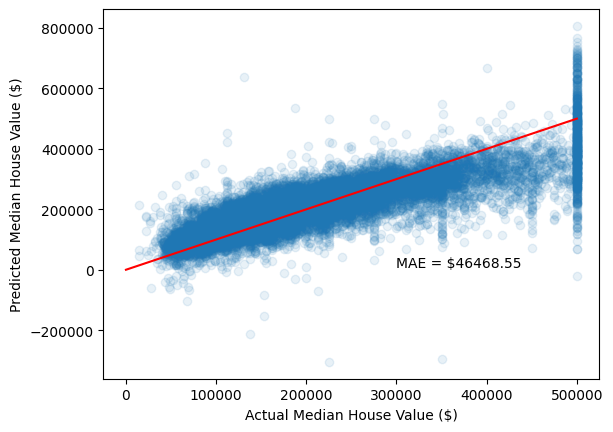

In [26]:
pipeline.fit(train, train["median_house_value"])
y_est = pipeline.predict(train)
plot_predictions(train["median_house_value"], y_est)